<a href="https://colab.research.google.com/github/navap3206-debug/hello-world/blob/main/T10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Carlos Santiago Nava Pulido

Vimos en clase el concepto de minimizar la varianza conjunta para realizar particiones en árboles de regresión; dado que en clasificación las salidas son categorías, no se puede usar el mismo concepto.

Investiga los siguientes conceptos y su conexión con las particiones en árboles de clasificación:

* GINI y Entropía: La impureza de Gini y la entropía se utilizan para determinar cómo dividir los datos (ramas). Ambas ayudan a determinar la heterogeneidad o pureza de los datos, esto ayuda a generar grupos definidos.
EL gini nos da la frecuencia con la que una muestra se clasificaría erroneamente si se hiciera al azar. En cambio la Entropía mide la incertidumbre en la distribución de clases de un nodo. Una mayor entropía indica un mayor desorden entre las etiquetas de clase.
(GeeksforGeeks, 2025)



* 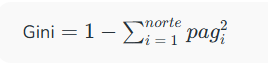

*pag* es la probabilidad del evento i

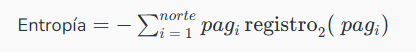

* Log Loss:
 En general se usa para modelos de clasificación, determina qué tan bien realiza clasificaciones el modelo ajustado durante la etapa de entrenamiento. Trabaja muy similar al MSE, si el resulyado es 1 tenemos un mal modelo y si el cercano a 0 relizas predicciones muy similares a las reales.
(Dialéktico, 2025b)

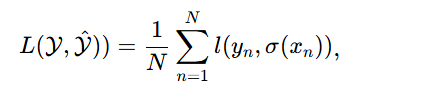

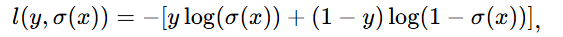

* ¿Cuál es la diferencia entre entropía y log loss?: COmo metodos "Entropía cruzada binaria"/"Pérdida logarítmica para clasificación binaria" se usan como conceptos iguales, pero en general el concepto de Entropía en la informatica abarca aplicaciones más amplias e incluso en Termodinámica. Como tal no se compará con una predicción real como lo hace log loss

## Escoge un dataset y realiza el ejemplo de hacer una partición para cada uno de los criterios de decisión.

In [3]:
import pandas as pd
import numpy as np
from google.colab import files
from sklearn.tree import DecisionTreeClassifier, export_text

In [2]:
dt = files.upload()

Saving brain_tumor_dataset.csv to brain_tumor_dataset.csv


In [5]:
df = pd.read_csv('brain_tumor_dataset.csv')

In [11]:
df.head(1)

,Patient_ID,Age,Gender,Tumor_Type,Tumor_Size,Location,Histology,Stage,Symptom_1,Symptom_2,Symptom_3,Radiation_Treatment,Surgery_Performed,Chemotherapy,Survival_Rate,Tumor_Growth_Rate,Family_History,MRI_Result,Follow_Up_Required
0,1,73,Male,1.0,5.375612,Temporal,Astrocytoma,III,Vision Issues,Seizures,Seizures,No,No,No,51.312579,0.111876,No,Positive,Yes


In [10]:
df['Tumor_Type'] = df['Tumor_Type'].map({'Malignant': 1, 'Benig': 0})

Simulamos un arbol;


In [29]:
#tamaño  > de 5
p_d = (sum(((df['Tumor_Type']== 1) & (df['Tumor_Size'] >= 5)).astype(int))/len(df))
q_d = (sum((df['Tumor_Type']!= 1 &  (df['Tumor_Size'] >= 5)).astype(int))/len(df))
p_d, q_d

(0.25845, 0.74155)

In [30]:
#tamaño < de 5
p_i = (sum(((df['Tumor_Type']== 1) & (df['Tumor_Size'] < 5)).astype(int))/len(df))
q_i = (sum((df['Tumor_Type']!= 1 &  (df['Tumor_Size'] < 5)).astype(int))/len(df))
p_i, q_i

(0.24305, 0.75695)

GINI:
$$Gini = 1 - \sum p_i^2$$
probabilidad de clasificar incorrectamente un elemento elegido al aza

In [31]:
gini = 1 - ((sum((df['Tumor_Type']== 1).astype(int))/len(df))**2 + (sum((df['Tumor_Type']!= 1).astype(int))/len(df))**2 )
print(gini)

gini_d = 1 - ((p_d)**2 + (q_d)**2)
print(gini_d)

gini_i = 1 - ((p_i)**2 + (q_i)**2)
print(gini_i)

0.49999550000000004
0.383307195
0.367953395


ENTROPY
$$Entropy = -\sum p_i \log_2(p_i)$$

el desorden o la incertidumbre

In [34]:
import math
p = (sum((df['Tumor_Type']== 1).astype(int))/len(df))
q = (sum((df['Tumor_Type']!= 1).astype(int))/len(df))
entropy = -p*math.log(p,2) - q*math.log(q,2)
print(entropy)

entropy_d = -p_d*math.log(p_d,2) - q_d*math.log(q_d,2)
print(entropy_d)

entropy_i = -p_i*math.log(p_i,2) - q_i*math.log(q_i,2)
print(entropy_i)

0.9999935078625779
0.8243983822162291
0.8000756394129307


LOGLOSS
En árboles de decisión, log_loss usa el logaritmo natural ln. Es matemáticamente proporcional a la Entropía.
$$LogLoss = -\sum p_i \ln(p_i)$$

In [37]:
LogLoss = -p*math.log(p) - q*math.log(q)
print(LogLoss)

LogLoss_d = -p_d*math.log(p_d)
print(LogLoss_d)

LogLoss_i = -p_i*math.log(p_i)
print(LogLoss_i)

0.6931426805531953
0.34969655491604595
0.343791331609008


##BIBLIOGRAFÍA
###GeeksforGeeks. (2025, 8 noviembre). Gini Impurity and Entropy in Decision Tree. GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/gini-impurity-and-entropy-in-decision-tree-ml/

###Dialéktico, D. (2025b, marzo 25). Función de pérdida de la regresión logística | Dialéktico. Dialéktico. https://dialektico.com/funcion-perdida-regresion-logistica/